# Correlation Difference Analysis

This notebook performs the correlation difference analysis between astrocyte and microglia modules in SCZ and Control groups. We reproduce the heatmap (Fig 2a) and the raincloud plot with Mann-Whitney U test (Fig 2b).

In [1]:
import os
import sys
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

# Add sources directory to path
sys.path.append('../../sources')
import wgcna_utils as wu
import corr_utils as cu

/data/home/swkim0523/.local/lib/python3.9/site-packages/setuptools_scm/version.py:11: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points


In [2]:
# Parameters
root_path = "/data/home/swkim0523/research/_SCZ_mic_ast_fin_0511/data/primary_cohort"
data_dir = f'{root_path}/pb_ct_filtered'
wgcna_dir = f'{root_path}/WGCNA_modules'
z_summary_thres = 2

os.makedirs('../../figures', exist_ok=True)

## 1. Load Data and Modules

In [3]:
# Load module dictionaries
mic_modules_raw, _ = wu.get_module_dict(
    'microglia', 
    os.path.join(wgcna_dir, 'df_zsummary_microglia.csv'), 
    os.path.join(wgcna_dir, 'modules_whole_microglia.csv'), 
    z_summary_thres=z_summary_thres
)

ast_modules_raw, _ = wu.get_module_dict(
    'astrocyte', 
    os.path.join(wgcna_dir, 'df_zsummary_astrocyte.csv'), 
    os.path.join(wgcna_dir, 'modules_whole_astrocyte.csv'), 
    z_summary_thres=z_summary_thres
)

# Add prefixes for plotting (e.g., Ast15, Mic5)
mic_modules = {f"Mic{k}": v for k, v in mic_modules_raw.items()}
ast_modules = {f"Ast{k}": v for k, v in ast_modules_raw.items()}

print(f"Microglia modules: {len(mic_modules)}")
print(f"Astrocyte modules: {len(ast_modules)}")

Module 1: 369 genes
Module 2: 1586 genes
Module 3: 1257 genes
Module 4: 59 genes
Module 5: 66 genes
Module 6: 58 genes
Module 8: 424 genes
Module 9: 221 genes
Module 10: 104 genes
Module 11: 109 genes
Module 12: 92 genes
Module 13: 131 genes
Module 14: 326 genes
Module 15: 249 genes
Module 16: 403 genes
Module 17: 91 genes
Module 18: 154 genes
Module 19: 207 genes
Module 20: 4342 genes
Module 21: 630 genes
Module 1: 474 genes
Module 2: 2888 genes
Module 3: 992 genes
Module 4: 195 genes
Module 5: 74 genes
Module 7: 618 genes
Module 8: 284 genes
Module 9: 126 genes
Module 10: 165 genes
Module 11: 104 genes
Module 12: 103 genes
Module 13: 322 genes
Module 14: 180 genes
Module 15: 363 genes
Module 16: 593 genes
Module 17: 247 genes
Module 18: 251 genes
Module 19: 3575 genes
Module 20: 723 genes
Microglia modules: 20
Astrocyte modules: 19


In [4]:
# Load pseudobulk AnnData objects
ast_control = sc.read_h5ad(os.path.join(data_dir, 'pb_astrocyte_control_filtered.h5ad'))
ast_scz     = sc.read_h5ad(os.path.join(data_dir, 'pb_astrocyte_scz_filtered.h5ad'))
mic_control = sc.read_h5ad(os.path.join(data_dir, 'pb_microglia_control_filtered.h5ad'))
mic_scz     = sc.read_h5ad(os.path.join(data_dir, 'pb_microglia_scz_filtered.h5ad'))

print(f"Astrocyte samples: Control={ast_control.n_obs}, SCZ={ast_scz.n_obs}")
print(f"Microglia samples: Control={mic_control.n_obs}, SCZ={mic_scz.n_obs}")

Astrocyte samples: Control=97, SCZ=94
Microglia samples: Control=97, SCZ=94


## 2. Correlation Difference Analysis

In [5]:
# Calculate module average expression (eigengene-like)
ast_control_eigen = cu.get_module_eigen_expression(ast_control, ast_modules)
ast_scz_eigen     = cu.get_module_eigen_expression(ast_scz, ast_modules)
mic_control_eigen = cu.get_module_eigen_expression(mic_control, mic_modules)
mic_scz_eigen     = cu.get_module_eigen_expression(mic_scz, mic_modules)

In [6]:
# Calculate cross-correlations (Microglia rows, Astrocyte columns)
r_control = cu.get_cross_corr(mic_control_eigen, ast_control_eigen)
r_scz     = cu.get_cross_corr(mic_scz_eigen, ast_scz_eigen)

# Sample sizes
n_control = mic_control.n_obs
n_scz     = mic_scz.n_obs

# Calculate difference and significance
delta_z, p_values = cu.calculate_delta_corr_significance(r_scz, n_scz, r_control, n_control)

## 3. Visualization (Reproducing Fig 2a)

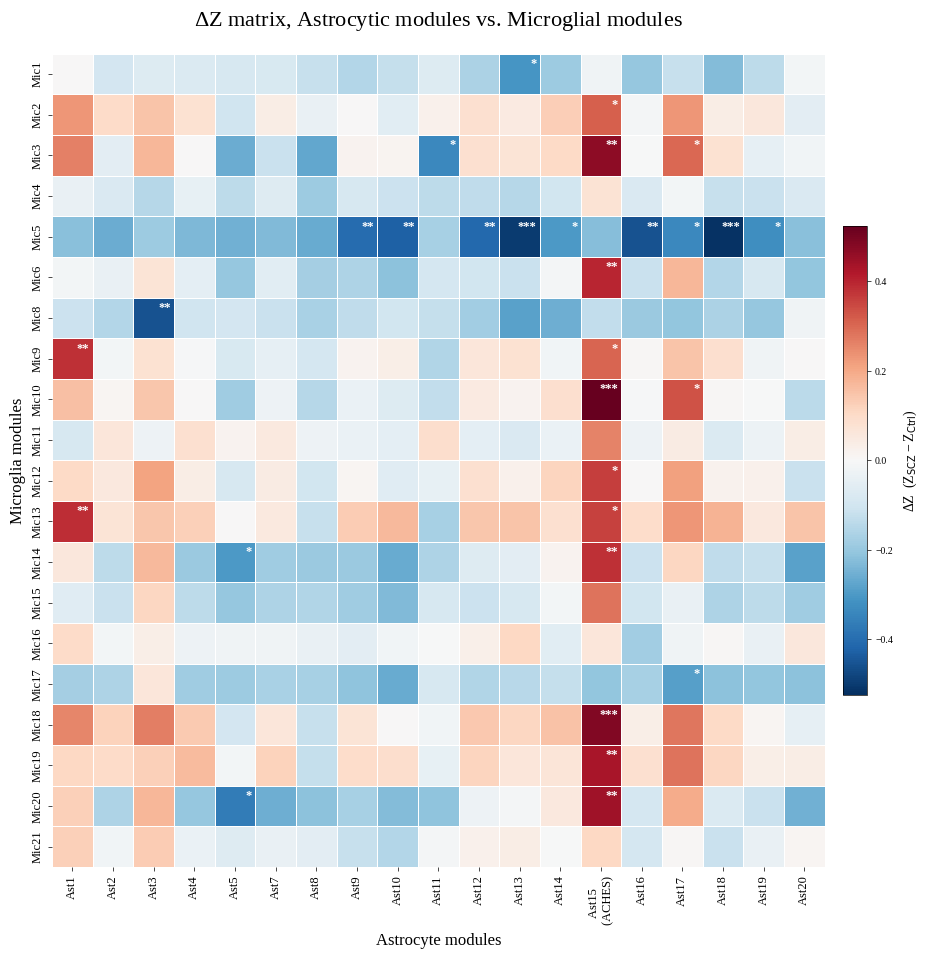

In [7]:
# Global style for consistent plotting
plt.rcParams.update({
    "font.family": "Liberation Serif",
    "font.size": 9,
    "axes.linewidth": 0.6,
    "mathtext.default": "regular",
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.pad": 3,
    "ytick.major.pad": 3,
})

cu.plot_delta_corr_heatmap(
    delta_z, 
    p_values, 
    title=r"$\Delta Z$ matrix, Astrocytic modules vs. Microglial modules",
    xlabel="Astrocyte modules",
    ylabel="Microglia modules",
    save_path="../../figures/fig2a_correlation_difference"
)

## 4. ΔZ Distribution Analysis (Reproducing Fig 2b)

We compare the distribution of ΔZ values for Ast15-Microglia pairs against all other module pairs using a Mann-Whitney U test and a raincloud plot.

Mann-Whitney U = 5907.0, p = 7.03e-07 (one-sided, greater)


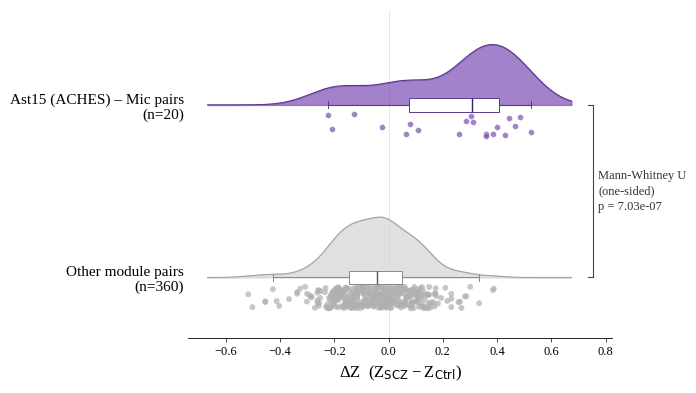

In [8]:
cu.plot_raincloud_dz(
    delta_z, 
    target_ast="Ast15", 
    save_path="../../figures/fig2b_raincloud"
)

In [9]:
# get r_rb 
1 - (2 * 5907) / (20 * 360)

-0.6408333333333334